# Project 2

## 1. Introduction

Modern processors achieve high performance through out-of-order (OoO) execution, which exploits instruction-level parallelism by scheduling instructions and utilizing hardware resources such as the reorder buffer (ROB) and issue width. These microarchitectural parameters play a critical role in determining overall performance, but increasing them also incurs higher hardware cost.

In this project, I study how different OoO design choices affect processor performance across a range of workloads, including compute-bound, memory-bound, and branch-intensive programs. I analyze key performance metrics such as IPC, branch misprediction rate, and cache miss rate under different configurations. Furthermore, I explore the trade-off between performance and hardware cost by defining a simple cost model and identifying the best configuration under a fixed budget.

## 2. Methodology

### 2.1 Experimental Environment

CPU: AMD EPYC 9334 32-Core Processor

Compiler: gcc (GCC) 11.5.0 20240719 (Red Hat 11.5.0-5)

OS: ubuntu:20.04

gem5 version: 25.1.0.0, SE mode activated

### 2.2 Setup & Measurement Method

**Processor model:**

We use the gem5 O3CPU model to evaluate out-of-order execution performance. The processor is configured with a fixed cache hierarchy and memory system to isolate the impact of core microarchitectural parameters.

**Cache hierarchy:**

L1I/L1D: Private L1 instruction and data caches, 32KB each  

L2: Unified L2 cache, 256KB  

Cacheline size: 64B  

All cache and memory parameters are kept constant across all experiments.

-------------------------------------------------------

**Workloads:**

We evaluate five microbenchmarks with different characteristics:

**compute1** 

A vector addition workload that performs simple arithmetic operations on large arrays

**compute2** 

A matrix multiplication workload with triple nested loops, performing intensive arithmetic computations. 

**memory1**

A random memory access workload that repeatedly accesses array elements using random indices.

**memory2**  

A pointer-chasing workload implemented as a linked list traversal.

**branch1:**  

A branch-intensive workload with frequent conditional branches based on random outcomes. 

-------------------------------------------------------

**Parameter sweep:**

We study the impact of key out-of-order execution parameters:

- **Reorder Buffer (ROB) size:** 32, 64, 128, 192  
- **Issue width:** 2, 4, 6, 8  

All other parameters remain fixed during each sweep.

-------------------------------------------------------

**Performance metrics:**

- **Instructions Per Cycle (IPC):**  
  system.cpu.ipc  

- **Branch misprediction rate:**  
  system.cpu.bac.branchMisspredict / system.cpu.bac.branches  

- **L1 data cache miss rate:**  
  system.cpu.dcache.overallMissRate  

- **Pipeline squashing cycles:**  
  system.cpu.decode.status::Squashing  

-------------------------------------------------------

**Cost model:**

To evaluate performance-cost trade-offs, we define a simple linear cost model:

cost = α × ROB + β × issueWidth  

where α = 1 and β = 16.

We select the best-performing configuration under a fixed cost budget based on IPC.

For the code, run:

In [ ]:
git clone https://github.com/gem5/gem5.git

cd gem5

gcc -O2 ch_1.c -o compute1

gcc -O2 ch_2.c -o compute2

gcc -O2 mh_1.c -o memory1

gcc -O2 mh_2.c -o memory2

gcc -O2 bh.c -o branch1

python3 run.py

python3 plot.py 

# 3. Results

| 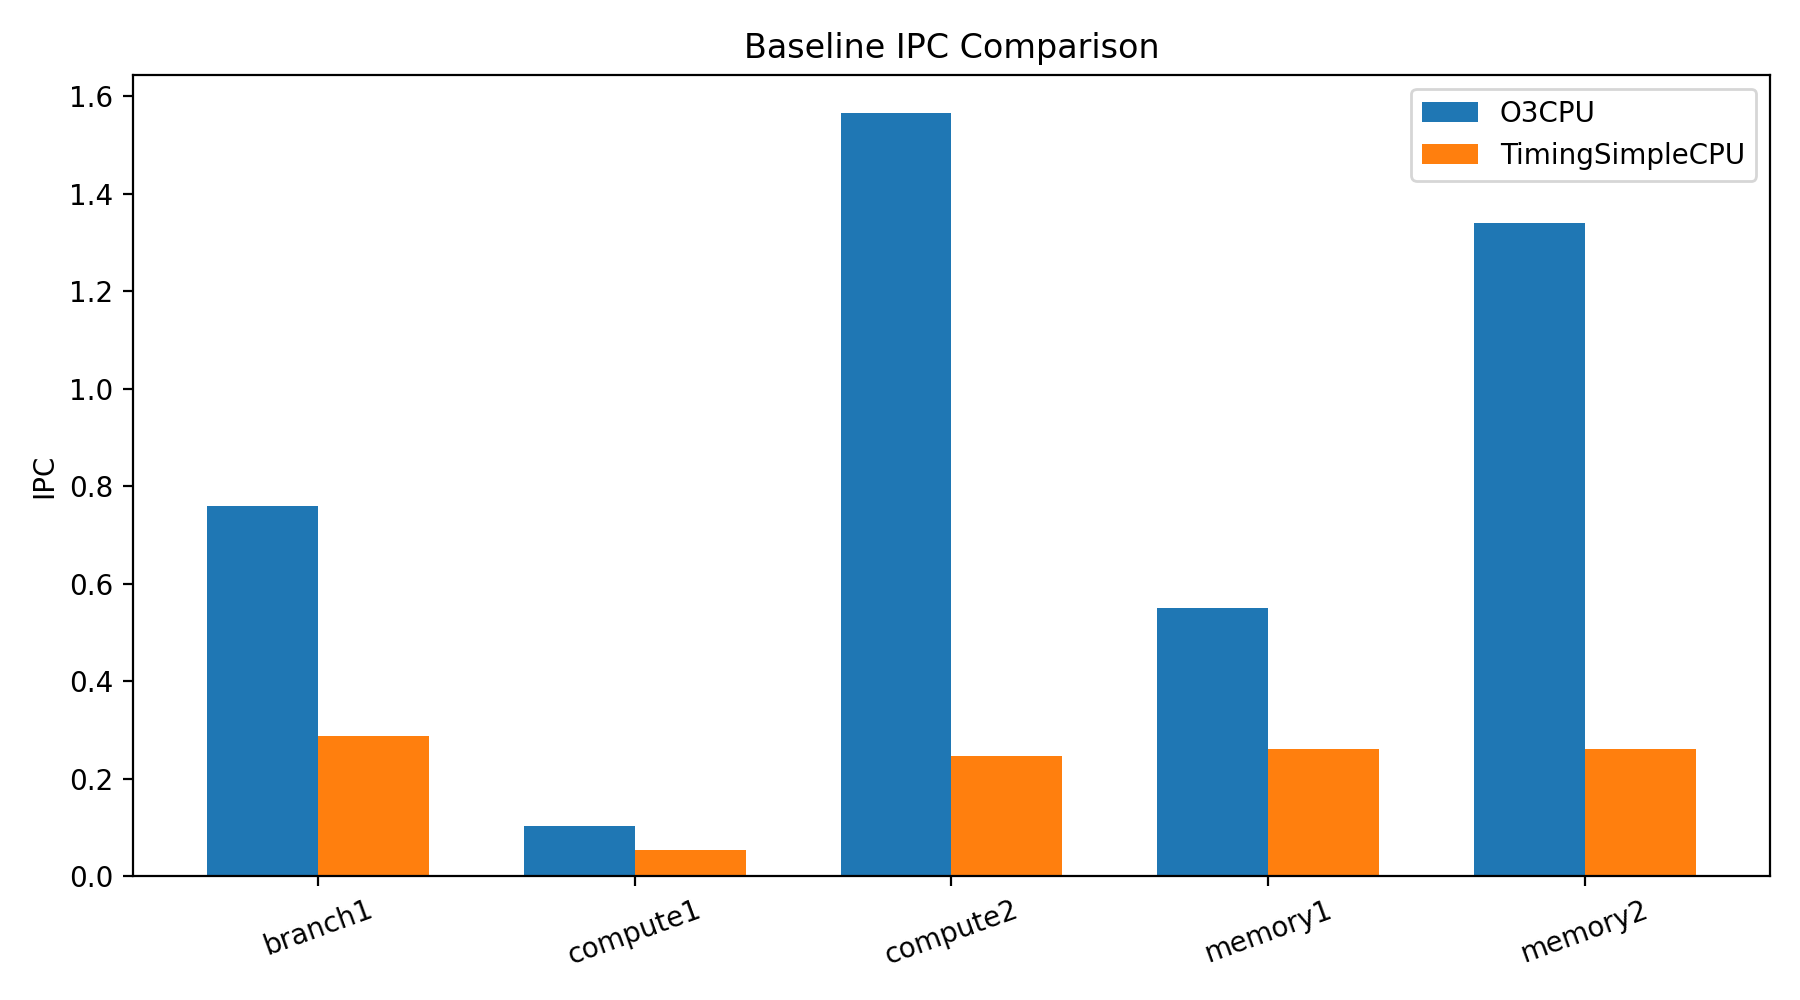|
|:----------------------------------------------------:|

This figure compares the IPC of the out-of-order O3CPU and the in-order TimingSimpleCPU across different workloads.

Overall, the O3CPU consistently outperforms the in-order model, with the largest gains observed in compute-intensive workloads such as compute2, where high instruction-level parallelism can be effectively exploited. In contrast, the performance improvement is more limited for memory-bound workloads (memory1, memory2) and branch-intensive workloads (branch1), where execution is constrained by memory latency and control flow dependencies rather than execution resources. This result highlights that the benefits of out-of-order execution are highly workload-dependent.


| 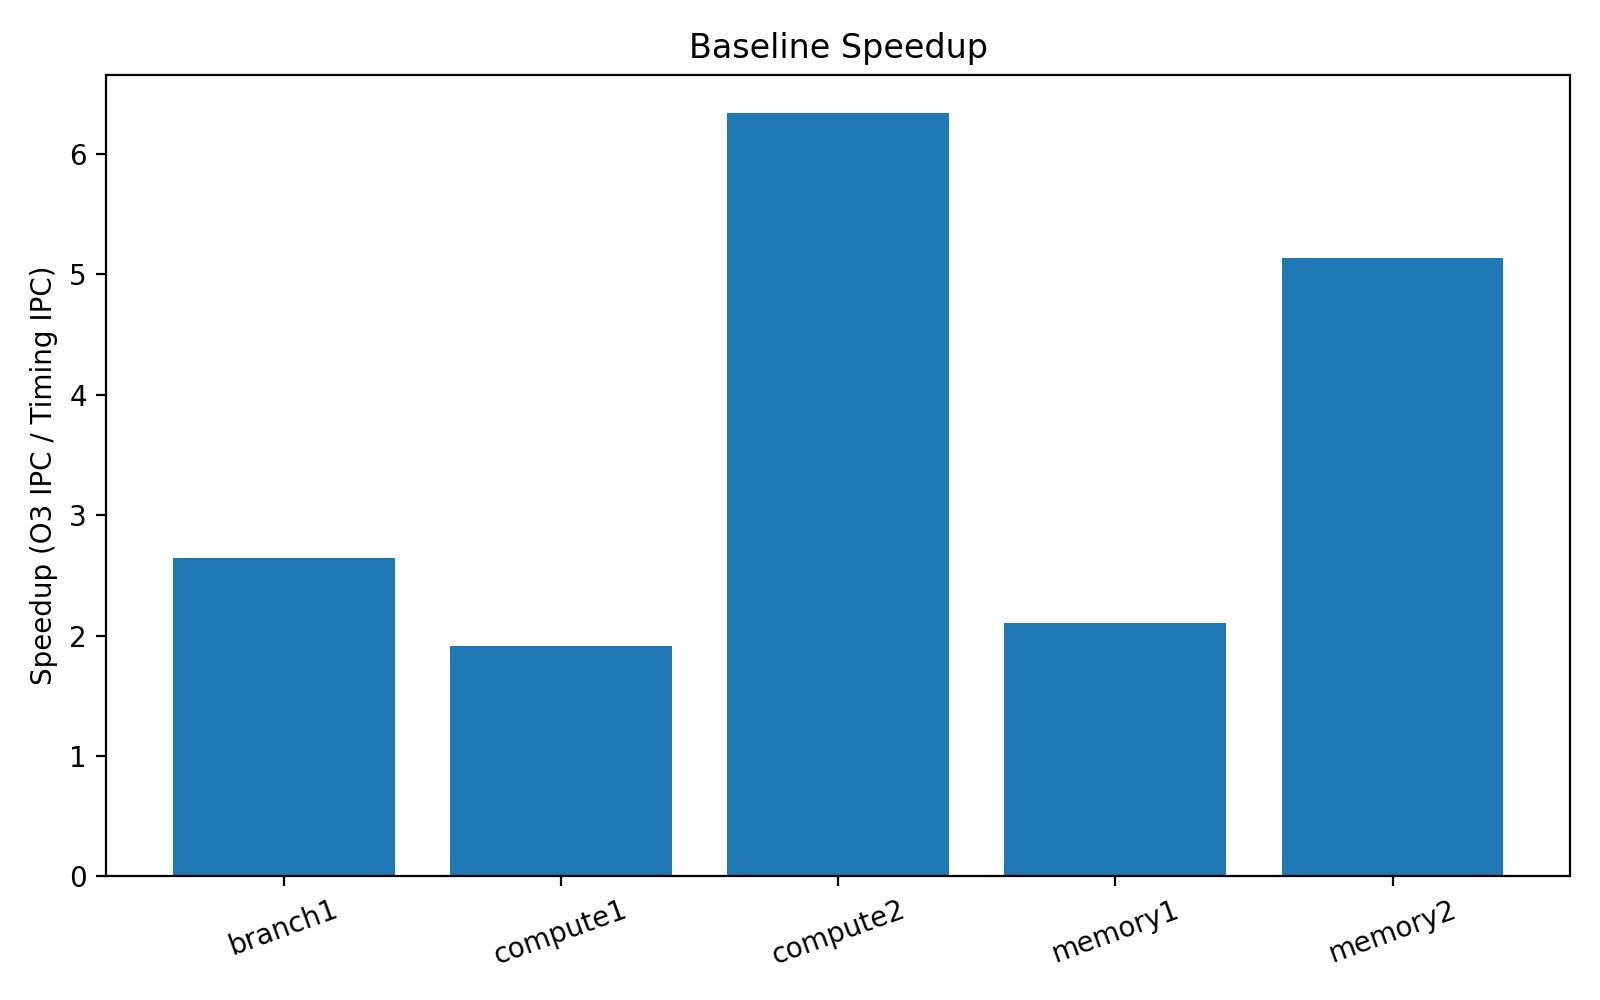|
|:----------------------------------------------------:|

This figure shows the speedup of the O3CPU over the TimingSimpleCPU across different workloads. 

The speedup is most significant for compute2, exceeding 6×, indicating that out-of-order execution can effectively exploit high instruction-level parallelism in compute-intensive workloads. Moderate improvements are observed in memory2 and branch1, while compute1 and memory1 show relatively lower speedups. This suggests that workloads with limited parallelism or higher memory/branch dependencies benefit less from out-of-order execution.

| 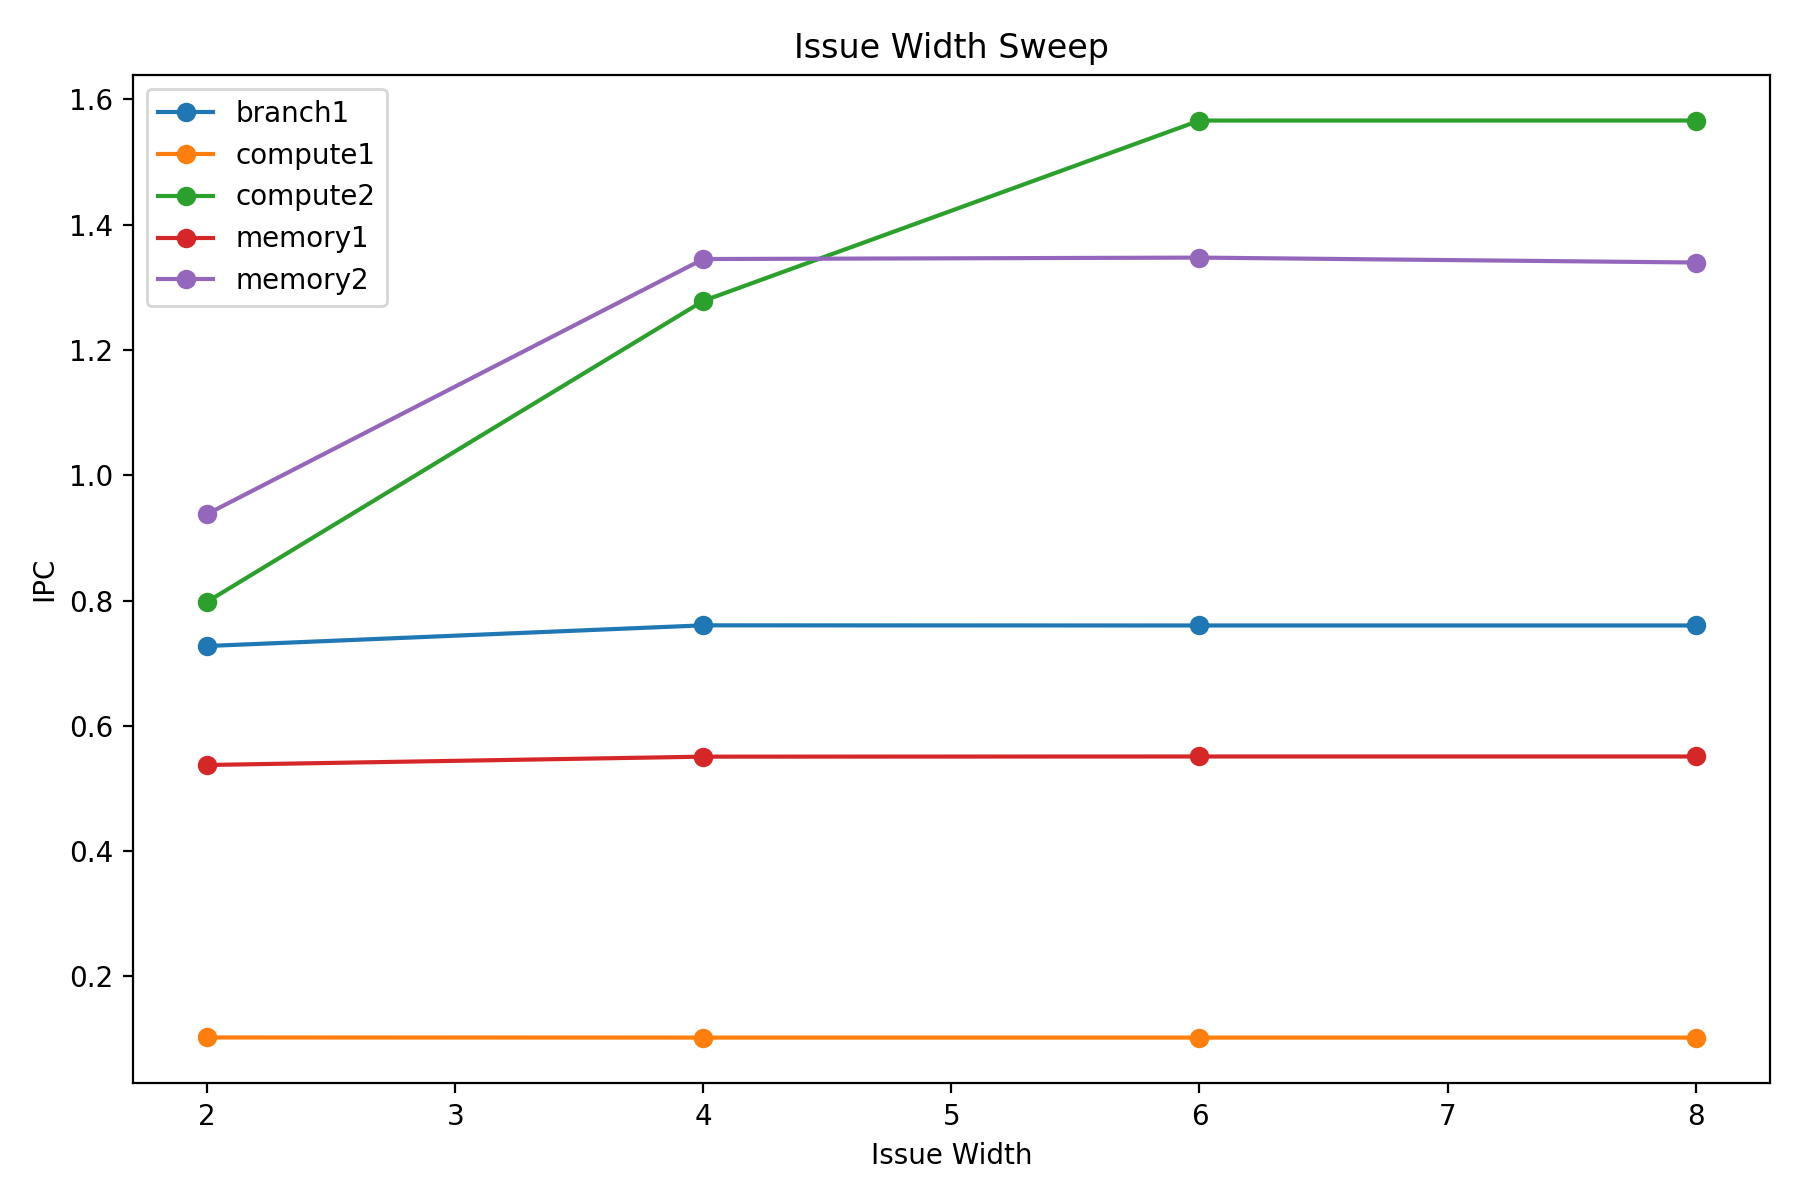|
|:----------------------------------------------------:|

This figure shows the impact of issue width on IPC across different workloads.

Increasing the issue width improves performance for compute-intensive workloads such as compute2, where IPC increases significantly from width 2 to 6 before saturating, indicating effective exploitation of instruction-level parallelism (ILP). In contrast, memory-bound workloads (memory1, memory2) and the branch-intensive workload (branch1) show only marginal improvement, as their performance is limited by memory latency and control dependencies rather than execution bandwidth.

Compute1 exhibits consistently low IPC and almost no sensitivity to issue width. Although categorized as a compute workload, it mainly consists of simple element-wise operations with frequent memory accesses, resulting in limited ILP. As a result, the processor cannot generate enough independent instructions to utilize wider issue bandwidth, and performance remains constrained by memory access latency rather than execution resources.

|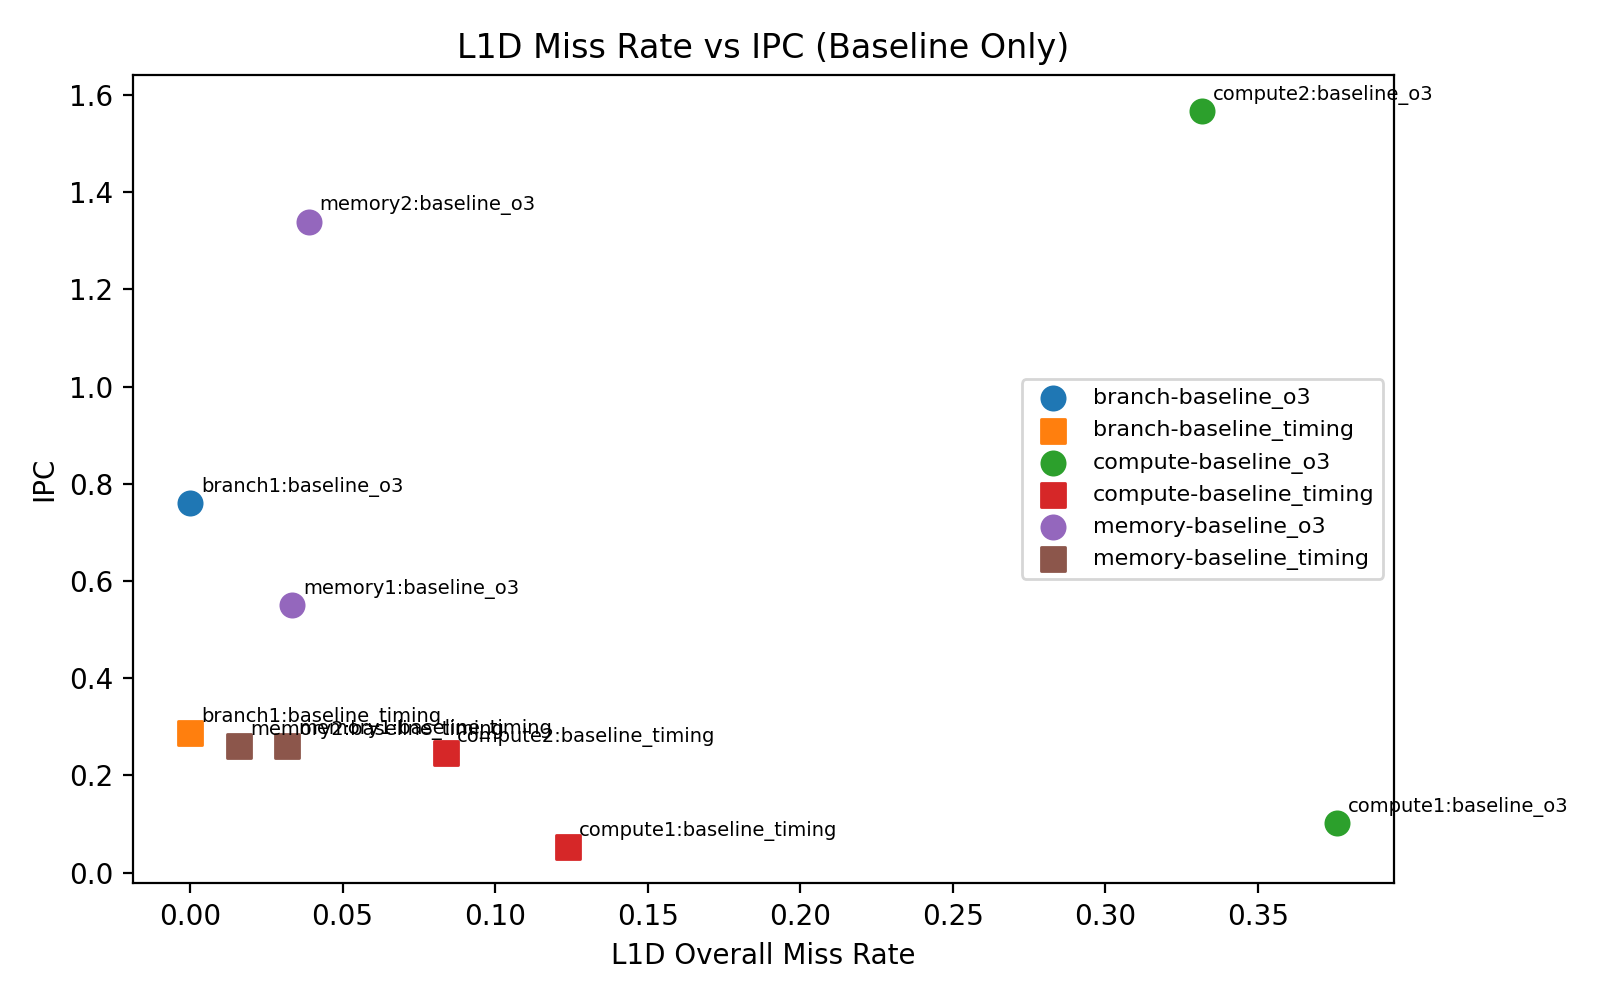|
|:----------------------------------------------------:|

This figure illustrates the relationship between L1D miss rate and IPC for both O3 and in-order baseline configurations. 

Compute2 achieves high IPC despite a relatively moderate miss rate, indicating that it can tolerate memory latency through high instruction-level parallelism. In contrast, compute1 shows both a high miss rate and very low IPC, suggesting that its performance is strongly limited by memory behavior and lacks sufficient parallelism to hide latency.

Memory-bound workloads (memory1, memory2) exhibit moderate miss rates with limited IPC, reflecting their sensitivity to memory access delays. Meanwhile, branch1 has a very low miss rate but only moderate IPC.

Additionally, the TimingSimpleCPU consistently shows low IPC across all workloads regardless of miss rate, highlighting its inability to overlap memory accesses and exploit parallelism.

|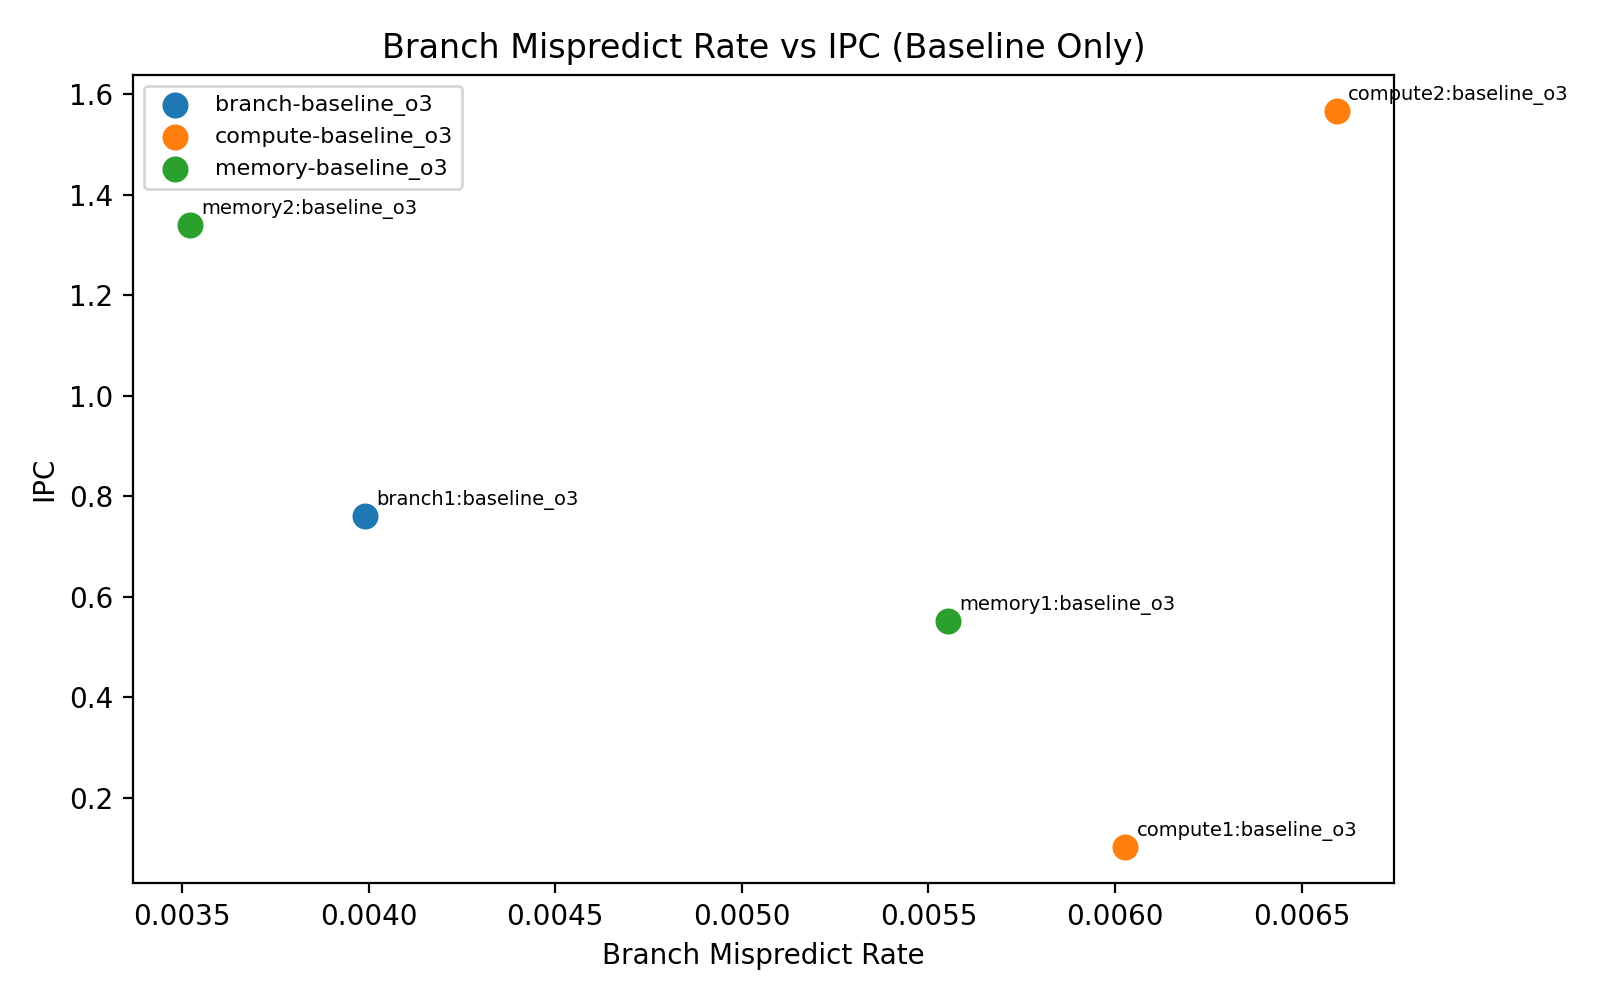|
|:----------------------------------------------------:|

This figure shows the relationship between branch misprediction rate and IPC for the baseline O3 configuration.

Branch1 has a relatively low misprediction rate but only moderate IPC, indicating that frequent control dependencies still limit performance even when prediction accuracy is high. In contrast, compute2 achieves the highest IPC despite having a slightly higher misprediction rate, suggesting that its abundant instruction-level parallelism (ILP) allows it to tolerate control-flow disruptions.

Similarly, memory2 maintains high IPC with low misprediction, showing that branch behavior is not a primary bottleneck. On the other hand, compute1 exhibits both relatively high misprediction rate and very low IPC, indicating that its performance is constrained by multiple factors, including limited ILP and memory access overhead, rather than branch behavior alone.

|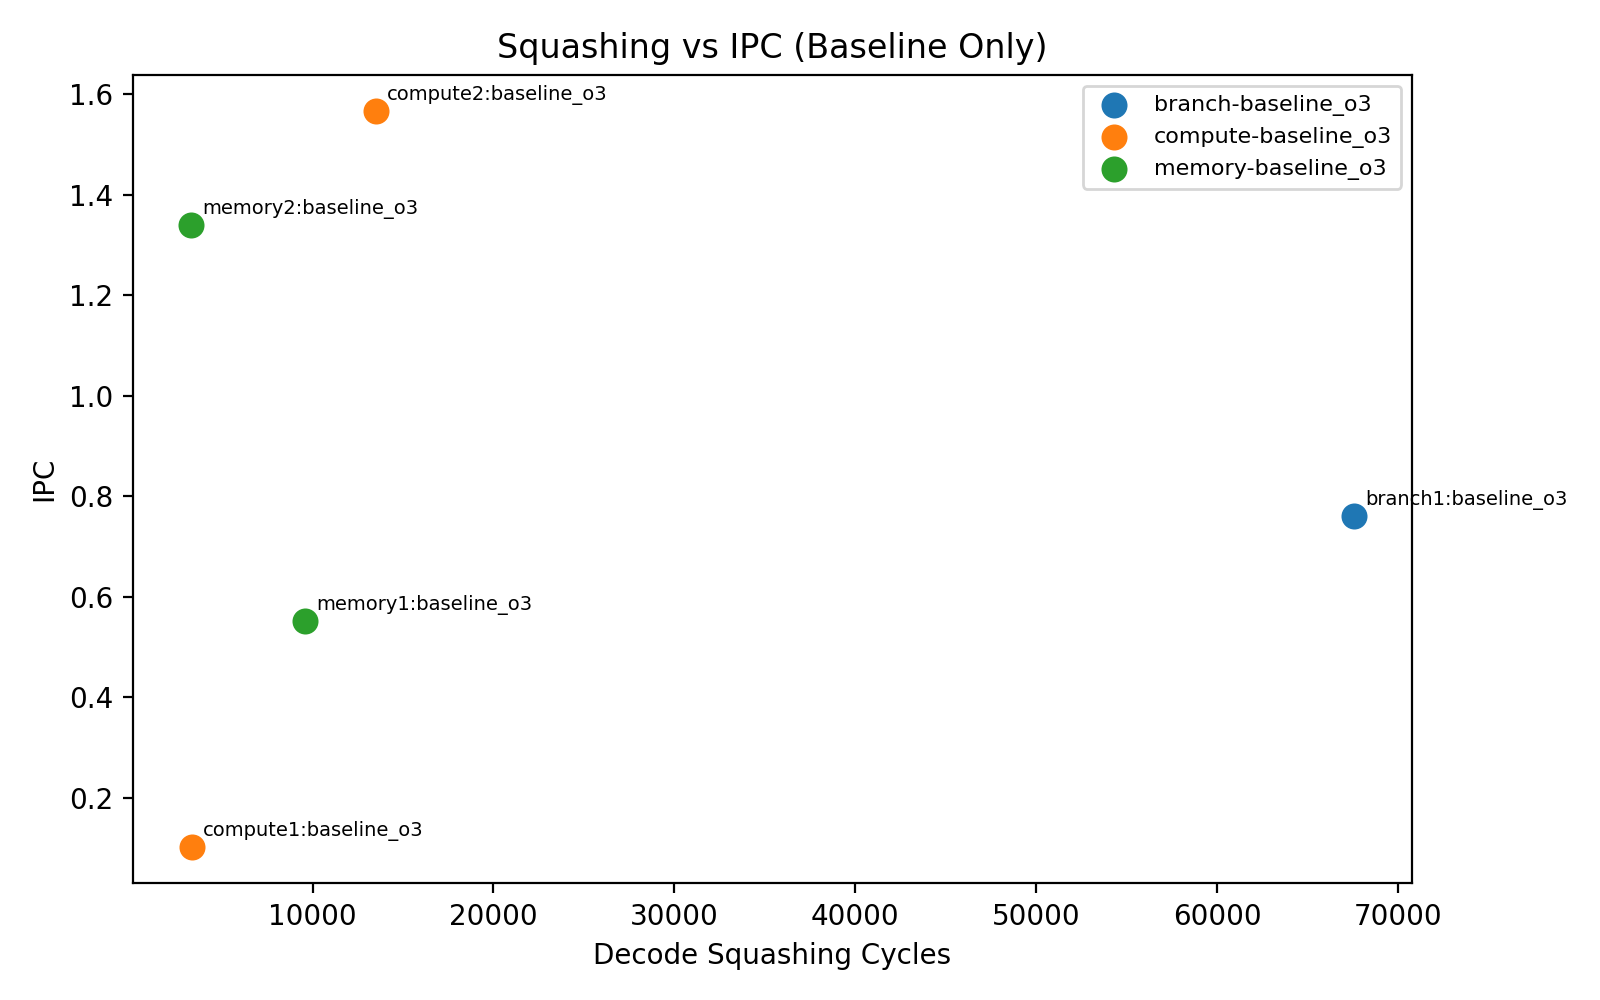|
|:----------------------------------------------------:|

This figure shows the relationship between decode squashing cycles and IPC for the baseline O3 configuration. Squashing cycles represent the number of cycles wasted due to incorrect speculation, primarily caused by branch mispredictions. In general, higher squashing cycles indicate more frequent pipeline flushes and lower execution efficiency.

The branch1 workload exhibits the highest squashing overhead and only moderate IPC, indicating significant control-flow disruption. In contrast, compute2 and memory2 achieve high IPC with relatively low squashing cycles, showing that branch behavior is not a major bottleneck. Meanwhile, compute1 has low IPC despite low squashing cycles, suggesting that its performance is limited by other factors such as memory access and limited parallelism.

|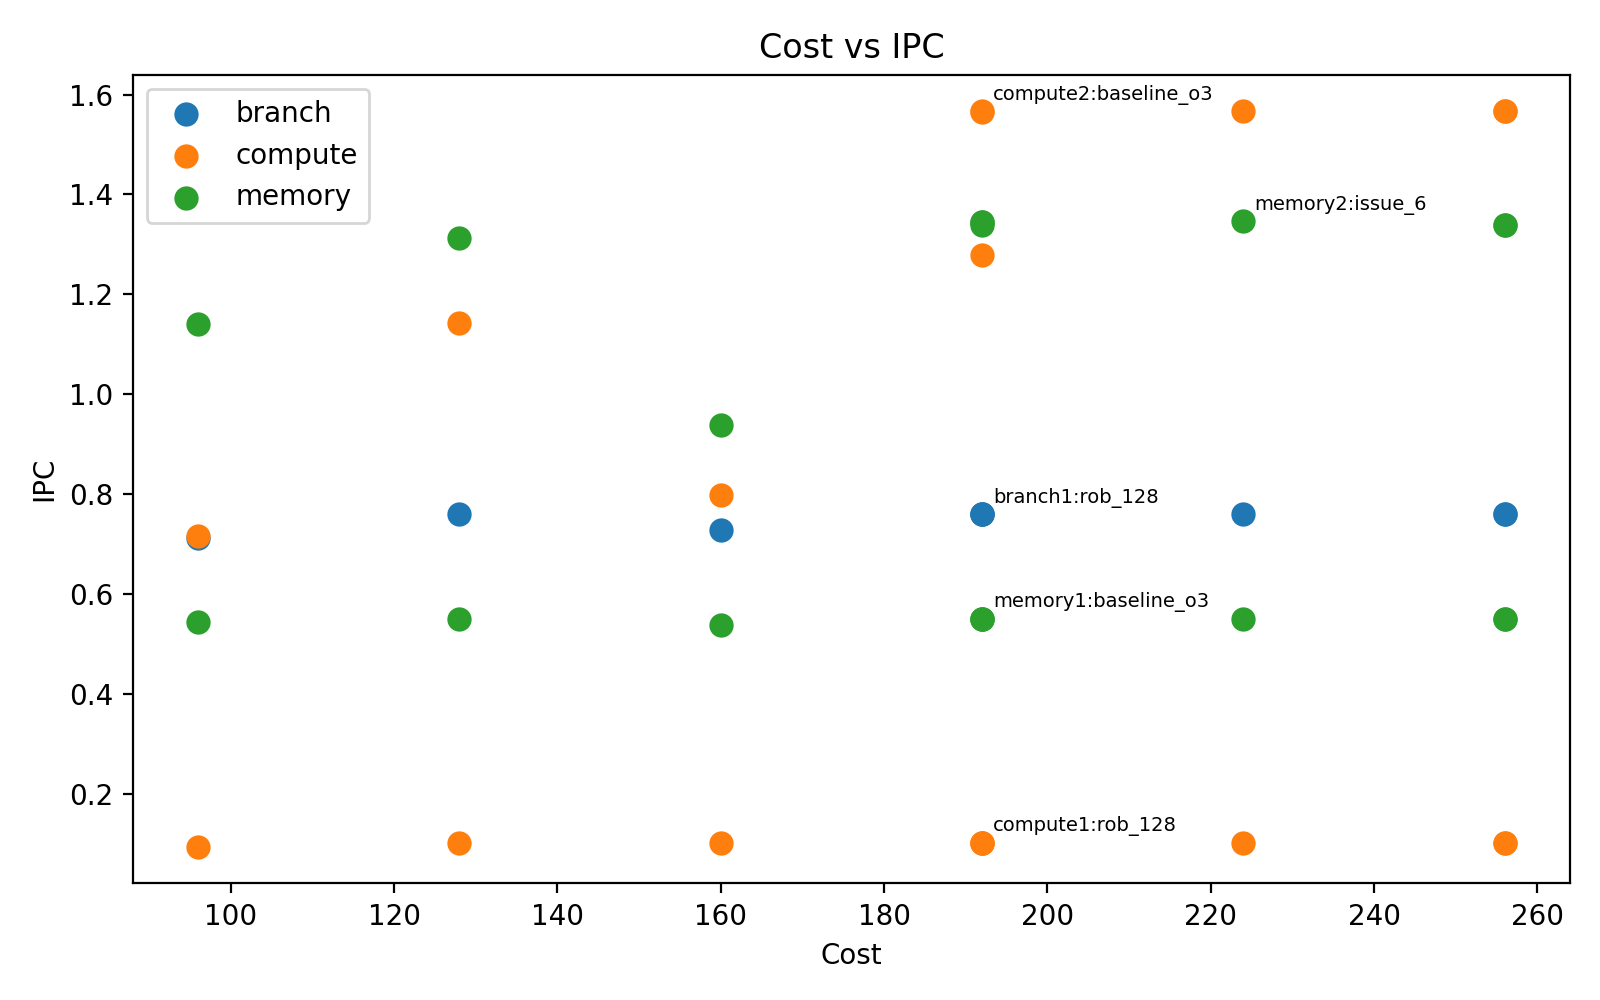|
|:----------------------------------------------------:|

This figure shows the trade-off between cost and IPC under different configurations. In general, increasing cost improves performance for compute-intensive workloads such as compute2. For memory-bound and branch-intensive workloads, increasing cost provides little to no performance improvement.

This demonstrates that simply allocating more hardware resources does not always lead to better performance. Instead, the optimal design depends on workload characteristics. Under a fixed budget, configurations that balance resource allocation and target the dominant bottleneck achieve the best performance-cost efficiency.